In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

!pip install -q -U "transformers>=4.50" "peft>=0.13" "bitsandbytes>=0.43" accelerate \
    sentencepiece rouge_score sacrebleu evaluate "torchao>=0.16.0" matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 106.2 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 29.2 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 389.2/389.2 kB 23.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 57.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 73.6 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 84.9 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 516.0/516.0 kB 29.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflict

In [2]:
from kaggle_secrets import UserSecretsClient
from huggingface_hub import login
try:
    HF_TOKEN = UserSecretsClient().get_secret("HF_TOKEN")
except Exception:
    HF_TOKEN = "hf_xxx"
login(HF_TOKEN)

In [3]:
import torch, gc
try: del model, base
except NameError: pass
gc.collect(); torch.cuda.empty_cache()

In [4]:

DATA_CSV     = "/kaggle/input/datasets/prettyntakirutimana/wambaza-training-data/wambaza_training_data.csv"
BASE_MODEL   = "google/gemma-3-1b-it"
ADAPTER_DIR  = "/kaggle/input/models/prettyntakirutimana/gemma3/transformers/default/1/gemma3-1b-en-kin-noswahili/checkpoint-1500"  

TRAINER_STATE_JSON = "/kaggle/input/models/prettyntakirutimana/gemma3/transformers/default/1/gemma3-1b-en-kin-noswahili/checkpoint-1500/trainer_state.json"

EXCLUDE_LANGS = ["Swa"]   
SEED = 42                 
MAX_NEW_TOKENS = 150
PER_LANG_EVAL_CAP = 40   

FIG_DIR = "/kaggle/working/figures"
os.makedirs(FIG_DIR, exist_ok=True)

import os
print("Adapter files:", os.listdir(ADAPTER_DIR))
assert "adapter_config.json" in os.listdir(ADAPTER_DIR), \
    "adapter_config.json not found — check ADAPTER_DIR points at the right folder"

Adapter files: ['adapter_model.safetensors', 'trainer_state.json', 'training_args.bin', 'adapter_config.json', 'README.md', 'tokenizer.json', 'tokenizer_config.json', 'chat_template.jinja', 'scheduler.pt', 'optimizer.pt', 'rng_state.pth']


In [5]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
from peft import PeftModel

tokenizer = AutoTokenizer.from_pretrained(ADAPTER_DIR)

bnb = BitsAndBytesConfig(
    load_in_4bit=True, bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16, bnb_4bit_use_double_quant=True,
)
base = AutoModelForCausalLM.from_pretrained(
    BASE_MODEL, quantization_config=bnb,
    torch_dtype=torch.bfloat16, device_map={"": 0}, attn_implementation="eager",
)
model = PeftModel.from_pretrained(base, ADAPTER_DIR)   # model object first, adapter path second
model.config.use_cache = True
model.eval()

eot_id = tokenizer.convert_tokens_to_ids("<end_of_turn>")
eos_id = tokenizer.eos_token_id
stop_ids = [t for t in {eot_id, eos_id} if t is not None]
print("Model loaded. Stop token ids:", stop_ids)

Skipping import of cpp extensions due to incompatible torch version. Please upgrade to torch >= 2.11.0 (found 2.10.0+cu128).


config.json:   0%|          | 0.00/899 [00:00<?, ?B/s]

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/2.00G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/340 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/215 [00:00<?, ?B/s]

Model loaded. Stop token ids: [1, 106]


In [6]:
@torch.no_grad()
def ask(question, max_new_tokens=MAX_NEW_TOKENS, use_repetition_guard=True):
    prompt = tokenizer.apply_chat_template([{"role":"user","content":question}],
                                           tokenize=False, add_generation_prompt=True)
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
    gen_kwargs = dict(
        max_new_tokens=max_new_tokens, do_sample=False,
        eos_token_id=stop_ids, pad_token_id=tokenizer.pad_token_id or tokenizer.eos_token_id,
    )
    if use_repetition_guard:
        gen_kwargs.update(repetition_penalty=1.3, no_repeat_ngram_size=3)
    out = model.generate(**inputs, **gen_kwargs)
    return tokenizer.decode(out[0][inputs.input_ids.shape[1]:], skip_special_tokens=True).strip()

print("Ready. Try it below.")

Ready. Try it below.


In [7]:

print(ask("Are there different types of HIV?, please answer this using simple medical terms."))

There are two known types of Hepatitis B: Acute hepatitis caused by infection with HBV and Chronic hepatitis which causes ongoing replication of the virusAcute hepatitis can be treated medically, while chronic hepatitis is a lifelong condition that requires treatmentAlcohol cessationAcute liver damageLiver transplantation


In [8]:
import pandas as pd, re

data = pd.read_csv(DATA_CSV)
data.columns = [c.strip().lower() for c in data.columns]
data = data[~data["lang"].isin(EXCLUDE_LANGS)].reset_index(drop=True)

def clean(t):
    t = str(t)
    t = re.sub(r"as of my last (knowledge update|update)", "", t, flags=re.IGNORECASE)
    return re.sub(r"\s{2,}", " ", t).strip()
data["question"] = data["question"].map(clean)
data["answer"]   = data["answer"].map(clean)
data = data[(data["question"] != "") & (data["answer"] != "")]
data = data.drop_duplicates(subset=["lang","question","answer"]).reset_index(drop=True)

print("Full pool (post-filter, for reference/graphs):")
print(data["lang"].value_counts())

eval_parts = []
for lang in data["lang"].unique():
    sub = data[data["lang"] == lang]
    eval_parts.append(sub.sample(frac=0.12, random_state=SEED))
eval_set = pd.concat(eval_parts, ignore_index=True).reset_index(drop=True)

print("\nHeld-out eval set:")
print(eval_set["lang"].value_counts())

if PER_LANG_EVAL_CAP:
    eval_set = eval_set.groupby("lang", group_keys=False).apply(
        lambda g: g.sample(min(PER_LANG_EVAL_CAP, len(g)), random_state=SEED)
    ).reset_index(drop=True)
    print(f"\nCapped to {PER_LANG_EVAL_CAP}/language for this run:")
    print(eval_set["lang"].value_counts())

Full pool (post-filter, for reference/graphs):
lang
en     7831
kin    7581
lug    3834
Name: count, dtype: int64

Held-out eval set:
lang
en     940
kin    910
lug    460
Name: count, dtype: int64

Capped to 40/language for this run:
lang
en     40
kin    40
lug    40
Name: count, dtype: int64


/tmp/ipykernel_58/3002173073.py:29: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  eval_set = eval_set.groupby("lang", group_keys=False).apply(


In [9]:
preds = []
for i, row in eval_set.iterrows():
    preds.append(ask(row["question"]))
    if (i + 1) % 20 == 0:
        print(f"  {i+1}/{len(eval_set)}")
eval_set["prediction"] = preds
print("Done.")

  20/120
  40/120
  60/120
  80/120
  100/120
  120/120
Done.


In [10]:
import evaluate
rouge = evaluate.load("rouge"); chrf = evaluate.load("chrf")

def score(preds, refs):
    r = rouge.compute(predictions=preds, references=refs, use_stemmer=True)
    c = chrf.compute(predictions=preds, references=[[x] for x in refs])
    return {"ROUGE-1": round(r["rouge1"]*100,2), "ROUGE-2": round(r["rouge2"]*100,2),
            "ROUGE-L": round(r["rougeL"]*100,2), "chrF": round(c["score"],2)}

rows = []
for lang in eval_set["lang"].unique():
    sub = eval_set[eval_set["lang"] == lang]
    s = score(sub["prediction"].tolist(), sub["answer"].tolist())
    s.update({"lang": lang, "n": len(sub)})
    rows.append(s)

overall = score(eval_set["prediction"].tolist(), eval_set["answer"].tolist())
overall.update({"lang": "ALL", "n": len(eval_set)})
rows.append(overall)

results = pd.DataFrame(rows)[["lang","n","ROUGE-1","ROUGE-2","ROUGE-L","chrF"]].sort_values("lang").reset_index(drop=True)
print(results.to_string(index=False))
results.to_csv("/kaggle/working/eval_scores.csv", index=False)

lang   n  ROUGE-1  ROUGE-2  ROUGE-L  chrF
 ALL 120    18.01     4.42    11.52 28.30
  en  40    28.52     9.90    18.34 34.78
 kin  40    14.44     2.25     9.02 27.07
 lug  40    10.98     1.20     7.25 24.10


In [11]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams.update({"figure.dpi": 150, "font.size": 11, "axes.spines.top": False,
                            "axes.spines.right": False})

def savefig(name):
    path = f"{FIG_DIR}/{name}.png"
    plt.tight_layout()
    plt.savefig(path, bbox_inches="tight")
    print("Saved", path)
    plt.show()

Saved /kaggle/working/figures/01_language_distribution.png


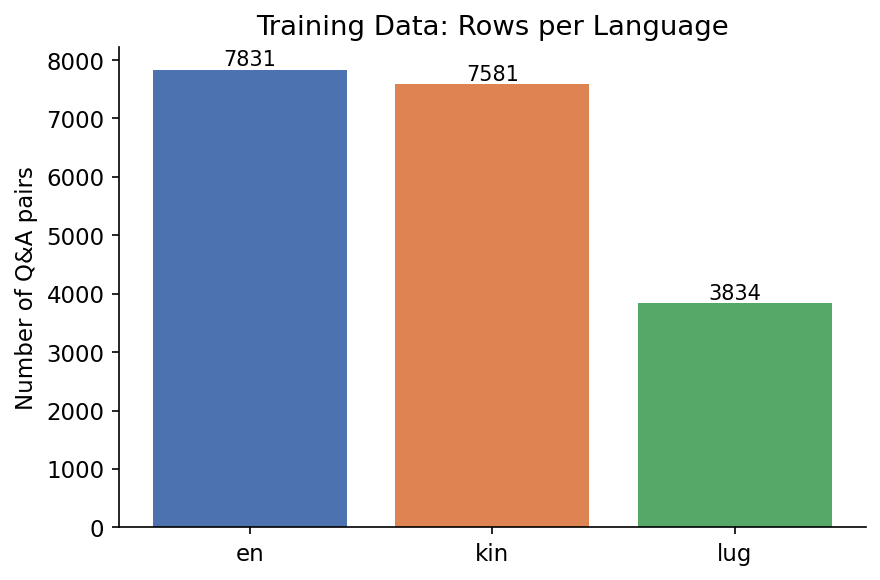

In [12]:
# language distribution in the full dataset
counts = data["lang"].value_counts()
plt.figure(figsize=(6,4))
bars = plt.bar(counts.index, counts.values, color=["#4C72B0","#DD8452","#55A868","#C44E52"][:len(counts)])
plt.title("Training Data: Rows per Language")
plt.ylabel("Number of Q&A pairs")
for b in bars:
    plt.text(b.get_x()+b.get_width()/2, b.get_height()+5, str(int(b.get_height())),
             ha="center", va="bottom", fontsize=10)
savefig("01_language_distribution")

Saved /kaggle/working/figures/02_token_length_distribution.png


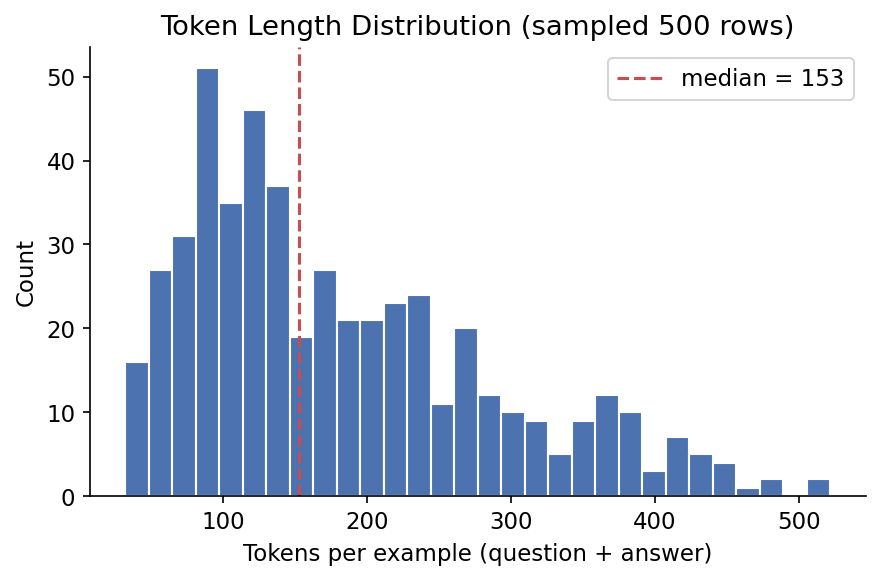

In [13]:
# token length distribution (helps justify MAX_SEQ_LEN choice in the report)
def n_tokens_text(q, a):
    msgs = [{"role":"user","content":q},{"role":"assistant","content":a}]
    text = tokenizer.apply_chat_template(msgs, tokenize=False, add_generation_prompt=False)
    return len(tokenizer(text).input_ids)

sample_for_lens = data.sample(min(500, len(data)), random_state=SEED)
lens = sample_for_lens.apply(lambda r: n_tokens_text(r["question"], r["answer"]), axis=1)

plt.figure(figsize=(6,4))
plt.hist(lens, bins=30, color="#4C72B0", edgecolor="white")
plt.axvline(lens.median(), color="#C44E52", linestyle="--", label=f"median = {int(lens.median())}")
plt.title("Token Length Distribution (sampled 500 rows)")
plt.xlabel("Tokens per example (question + answer)")
plt.ylabel("Count")
plt.legend()
savefig("02_token_length_distribution")

Saved /kaggle/working/figures/03_scores_by_language.png


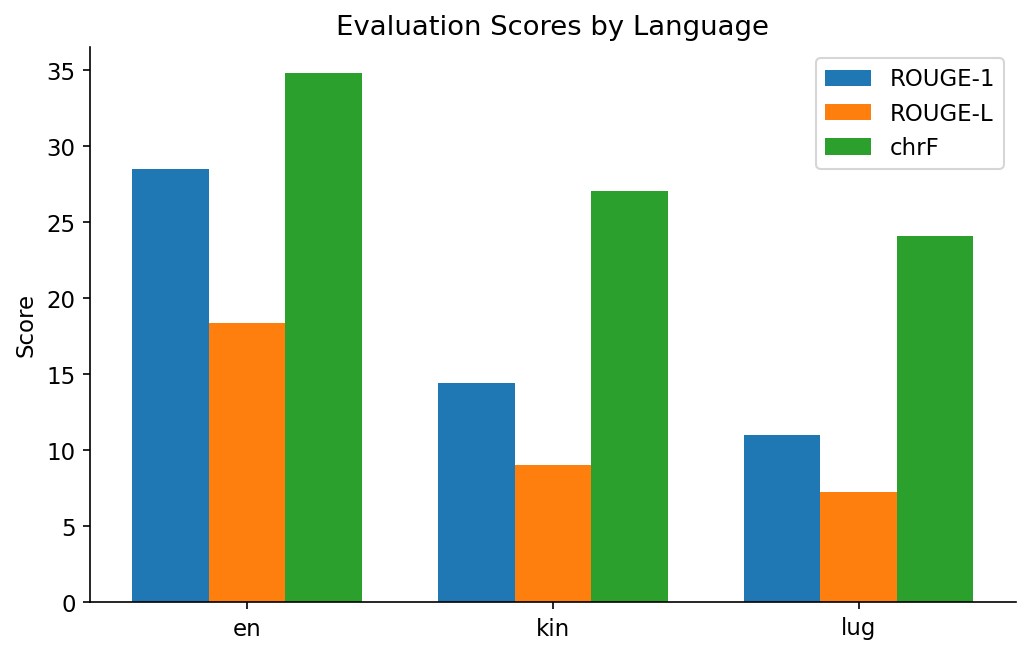

In [14]:
# ROUGE/chrF per language, grouped bar chart
plot_df = results[results["lang"] != "ALL"]
metrics = ["ROUGE-1", "ROUGE-L", "chrF"]
x = range(len(plot_df))
width = 0.25

plt.figure(figsize=(7,4.5))
for i, m in enumerate(metrics):
    plt.bar([xi + i*width for xi in x], plot_df[m], width=width, label=m)
plt.xticks([xi + width for xi in x], plot_df["lang"])
plt.ylabel("Score")
plt.title("Evaluation Scores by Language")
plt.legend()
savefig("03_scores_by_language")

Saved /kaggle/working/figures/04_training_loss_curve.png


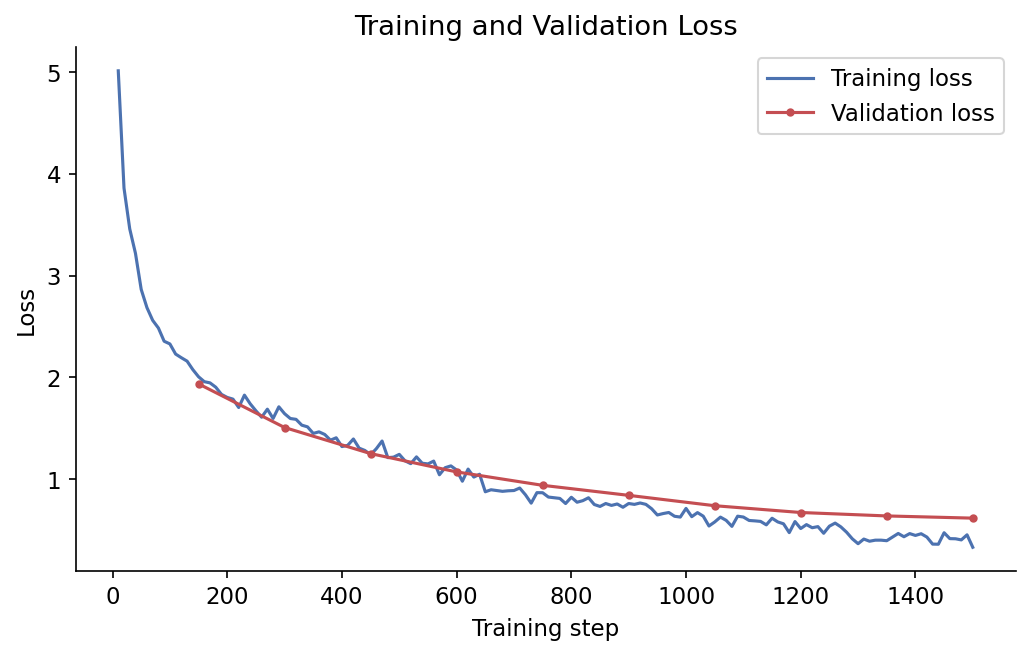

In [15]:
#  training loss curve 
import json as _json

if TRAINER_STATE_JSON and os.path.exists(TRAINER_STATE_JSON):
    state = _json.load(open(TRAINER_STATE_JSON))
    log = state.get("log_history", [])
    train_steps = [e["step"] for e in log if "loss" in e]
    train_loss  = [e["loss"] for e in log if "loss" in e]
    eval_steps  = [e["step"] for e in log if "eval_loss" in e]
    eval_loss   = [e["eval_loss"] for e in log if "eval_loss" in e]

    plt.figure(figsize=(7,4.5))
    if train_steps:
        plt.plot(train_steps, train_loss, label="Training loss", color="#4C72B0")
    if eval_steps:
        plt.plot(eval_steps, eval_loss, label="Validation loss", color="#C44E52", marker="o", markersize=3)
    plt.xlabel("Training step")
    plt.ylabel("Loss")
    plt.title("Training and Validation Loss")
    plt.legend()
    savefig("04_training_loss_curve")
else:
    print("TRAINER_STATE_JSON not set or not found — skipping loss-curve figure.")
    print("To include it: point TRAINER_STATE_JSON at a saved checkpoint-XXXX/trainer_state.json")

Saved /kaggle/working/figures/05_rougeL_overall_vs_language.png


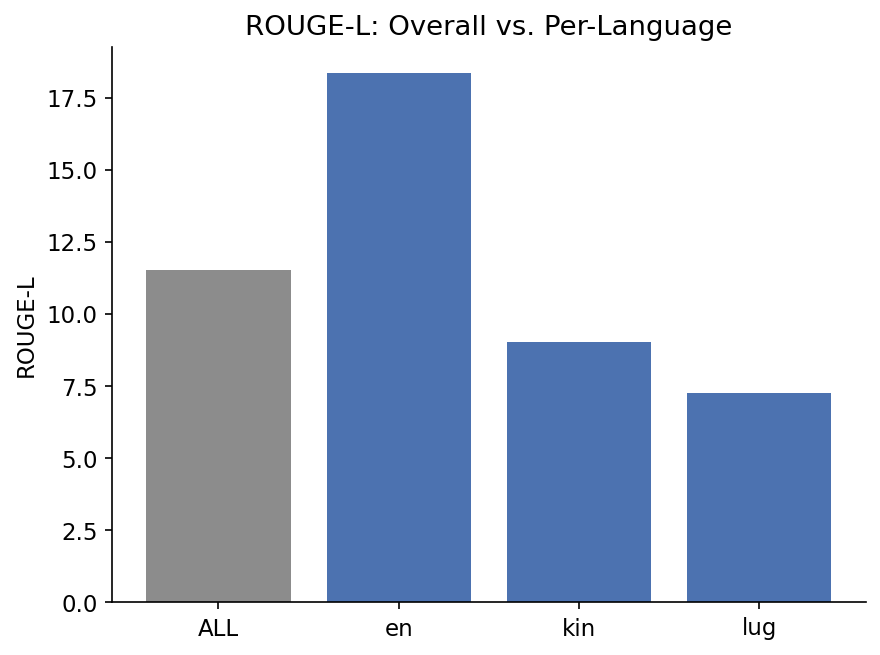

In [16]:
# overall vs per-language comparison, single summary chart 
plt.figure(figsize=(6,4.5))
all_langs = results["lang"].tolist()
colors = ["#8C8C8C" if l == "ALL" else "#4C72B0" for l in all_langs]
plt.bar(all_langs, results["ROUGE-L"], color=colors)
plt.ylabel("ROUGE-L")
plt.title("ROUGE-L: Overall vs. Per-Language")
savefig("05_rougeL_overall_vs_language")

In [17]:
eval_set[["lang","question","answer","prediction"]].to_csv(
    "/kaggle/working/eval_predictions_full.csv", index=False)

for lang in eval_set["lang"].unique():
    sub = eval_set[eval_set["lang"] == lang].head(3)
    for _, row in sub.iterrows():
        print(f"=== {lang} ===")
        print("Q   :", row["question"][:150])
        print("REF :", row["answer"][:200])
        print("PRED:", row["prediction"][:200])
        print("-"*70)

=== en ===
Q   : What kinds of Trich are there?, please answer this using simple medical terms.
REF : 1. Urogenital trichomoniasis 2. Oral trichomoniasis. 3. Rectal trichomoniasis
PRED: 1. Urogenital trichomoniasis 2. Oral trichamoniasis (Trich in oral mucosa)3. Rectal trichomonitis
----------------------------------------------------------------------
=== en ===
Q   : When should I tell anyone about my HIV status?
REF : If you have just found out about your status, take the time to process the information before choosing to share it with someone.
PRED: The best time to talk is when you are both in a good place emotionally and physically. It may be difficult at first but it gets easier with practice. Start by telling one trusted person, like your par
----------------------------------------------------------------------
=== en ===
Q   : Where did HSV start?, please answer this using simple medical terms.
REF : Genital Herpes or Herpes Simplex Virus (HSV), also known as Herpes originate

In [18]:
for lang in eval_set["lang"].unique():
    if lang.lower().startswith("eng"):
        continue
    sub = eval_set[eval_set["lang"] == lang][["question","answer","prediction"]]
    fname = f"/kaggle/working/{lang}_native_review.csv"
    sub.to_csv(fname, index=False)
    print(f"Saved {len(sub)} rows -> {fname}")

print("\nAll outputs in /kaggle/working/:")
print("  eval_scores.csv")
print("  eval_predictions_full.csv")
print("  <lang>_native_review.csv (per non-English language)")
print("  figures/01_language_distribution.png")
print("  figures/02_token_length_distribution.png")
print("  figures/03_scores_by_language.png")
print("  figures/04_training_loss_curve.png (if TRAINER_STATE_JSON was set)")
print("  figures/05_rougeL_overall_vs_language.png")

Saved 40 rows -> /kaggle/working/en_native_review.csv
Saved 40 rows -> /kaggle/working/kin_native_review.csv
Saved 40 rows -> /kaggle/working/lug_native_review.csv

All outputs in /kaggle/working/:
  eval_scores.csv
  eval_predictions_full.csv
  <lang>_native_review.csv (per non-English language)
  figures/01_language_distribution.png
  figures/02_token_length_distribution.png
  figures/03_scores_by_language.png
  figures/04_training_loss_curve.png (if TRAINER_STATE_JSON was set)
  figures/05_rougeL_overall_vs_language.png
